<a href="https://colab.research.google.com/github/matrix-engineer-learner/rithwik-systems-learning-portfolio/blob/main/FLUX_Being.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

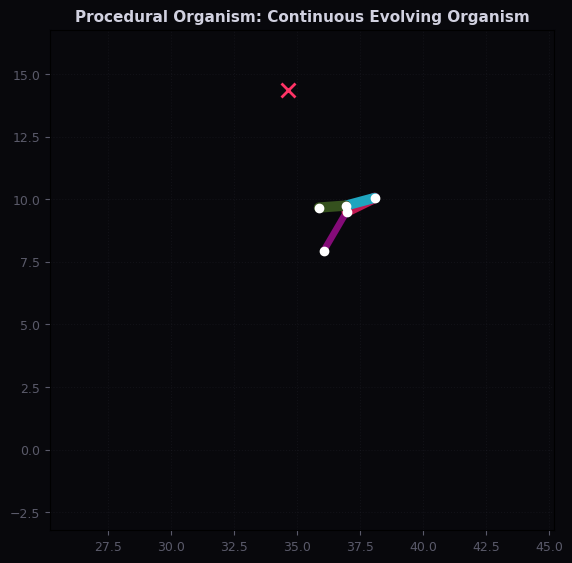

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import time
import random

# Disable automatic static plot generation
plt.ioff()

# --- EVOLUTION DATA CORE ---
max_segments = 12
current_active = 6.0
current_lengths = np.random.uniform(0.5, 2.0, max_segments)
current_angles = np.random.uniform(0, 2 * np.pi, max_segments)
current_colors = np.random.rand(max_segments, 3)
current_thickness = np.random.uniform(4, 14, max_segments)

target_active = current_active
target_lengths = np.copy(current_lengths)
target_angles = np.copy(current_angles)
target_colors = np.copy(current_colors)
target_thickness = np.copy(current_thickness)

# Spatial position trackers
creature_pos = np.array([0.0, 0.0])
target_food = np.array([random.uniform(-6, 6), random.uniform(-6, 6)])
cam_x, cam_y = 0.0, 0.0

def generate_new_target():
    global target_active, target_lengths, target_angles, target_colors, target_thickness, target_food
    target_active = float(random.randint(4, max_segments))
    target_lengths = np.random.uniform(0.5, 2.2, max_segments)
    target_angles = np.random.uniform(0, 2 * np.pi, max_segments)
    target_colors = np.random.rand(max_segments, 3)
    target_thickness = np.random.uniform(5, 14, max_segments)
    target_food = creature_pos + np.random.uniform(-8, 8, 2)

def update_evolution(rate=0.08):
    global current_active, current_lengths, current_angles, current_colors, current_thickness, creature_pos
    current_active += (target_active - current_active) * rate
    current_lengths += (target_lengths - current_lengths) * rate

    angle_diff = np.atan2(np.sin(target_angles - current_angles), np.cos(target_angles - current_angles))
    current_angles += angle_diff * rate
    current_colors += (target_colors - current_colors) * rate
    current_thickness += (target_thickness - current_thickness) * rate

    dir_to_food = target_food - creature_pos
    dist = np.linalg.norm(dir_to_food)
    if dist > 0.5:
        creature_pos += (dir_to_food / dist) * 0.20

def get_coordinates(time_step):
    # FIXED: Extract positions as scalar numbers instead of structural arrays
    x = [float(creature_pos[0])]
    y = [float(creature_pos[1])]
    curr_x, curr_y = x[0], y[0]
    visible_segments = int(np.round(current_active))

    for i in range(visible_segments):
        dynamic_angle = current_angles[i] + 0.35 * np.sin(time_step * 2.2 + i)
        curr_x += current_lengths[i] * np.cos(dynamic_angle)
        curr_y += current_lengths[i] * np.sin(dynamic_angle)
        x.append(curr_x)
        y.append(curr_y)

    return x, y, visible_segments

# --- SETUP RENDER CANVAS ---
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.set_facecolor('#08080c')
fig.patch.set_facecolor('#08080c')

# Build persistent visual objects
lines = [ax.plot([], [], lw=8, solid_capstyle='round')[0] for _ in range(max_segments)]
dots, = ax.plot([], [], 'o', color='#ffffff', ms=6, zorder=5)
food_marker, = ax.plot([], [], 'x', color='#ff3366', ms=10, mew=2, zorder=2)

# Push the canvas window handle onto Colab output area
display_handle = display(fig, display_id=True)

frame = 0
try:
    while True:
        if frame % 35 == 0 or np.linalg.norm(target_food - creature_pos) < 0.8:
            generate_new_target()

        update_evolution(rate=0.25)
        x, y, active_count = get_coordinates(frame * 0.15)

        # Camera tracking calculations using standard values
        cam_x += (float(creature_pos[0]) - cam_x) * 0.10
        cam_y += (float(creature_pos[1]) - cam_y) * 0.10

        ax.set_xlim(cam_x - 10, cam_x + 10)
        ax.set_ylim(cam_y - 10, cam_y + 10)
        ax.grid(True, linestyle=':', alpha=0.15, color='#4a4a5a')
        ax.tick_params(colors='#5a5a6a', labelsize=9)
        ax.set_title("Procedural Organism: Continuous Evolving Organism", color='#d1d1e0', fontsize=11, weight='bold')

        food_marker.set_data([float(target_food[0])], [float(target_food[1])])

        pulse = 0.15 * np.sin(frame * 0.3) + 0.85
        for i in range(max_segments):
            if i < active_count:
                lines[i].set_data([x[i], x[i+1]], [y[i], y[i+1]])
                lines[i].set_linewidth(current_thickness[i] * pulse)
                glow_color = np.clip(current_colors[i] * (0.8 + 0.3 * np.sin(frame * 0.2 + i)), 0, 1)
                lines[i].set_color(glow_color)
            else:
                lines[i].set_data([], [])

        dots.set_data(x, y)

        display_handle.update(fig)

        time.sleep(0.001)
        frame += 1

except KeyboardInterrupt:
    print("\nSimulation paused safely.")
